# Практическое задание «Поиск выбросов»

## Шаблон для выполнения

### Часть 1. Выявление и визуализация выбросов

В этом задании вы будете работать с реальным датасетом, в котором содержится информация о более чем 50 000 бриллиантах. У каждого бриллианта есть несколько характеристик:

• **carat**: вес бриллианта. Более крупные бриллианты, как правило, дороже.

• **cut**: качество огранки. Измеряется по градации качества: "Fair", "Good", "Very Good",
"Premium", "Ideal".

• **color**: оценка цвета бриллианта. Ранжируется от "J" (худшая) to "D" (лучшая).

• **clarity**: чистота бриллианта. Описывается кодом (по возрастанию качества): "I1" (худшая), "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF" (лучшая).

• **price**: цена бриллианта в долларах США.

Измерения:

• **x, y, z**, длина, ширина и глубина в мм

• Глубина и площадка - это отношения (в %)

• **depth** = 2 z / (x+y)

• **table** = ширина верха / наибольшая ширина

![image.png](https://u.netology.ru/backend/uploads/lms/content_assets/file/14718/tg_image_378460715.png)

1.1. Загрузите файл `diamonds.csv` из библиотеки seaborn. Проведите предварительный анализ:

 - Получите базовые статистики датафрейма.
 - Найдите топ-3 столбца с наибольшим количеством пропусков.
 - Посмотрите уникальные значения в столбцах `carat`, `depth`, `table` и `price`. Есть ли там странные значения?
 - Для каждой из четырх переменных постройте гистограмму и ящик с усами (boxplot).

*Объясните природу выбросов: являются ли они естественными или синтетическими?*

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
diamonds = sns.load_dataset('diamonds')
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
# пропуски
(diamonds.isna().mean()*100).sort_values()

,0
carat,0.0
cut,0.0
color,0.0
clarity,0.0
depth,0.0
table,0.0
price,0.0
x,0.0
y,0.0
z,0.0


In [ ]:
print(f'Уникальные значения столбца carat:\n {diamonds['carat'].unique()}')
print(f'\nУникальные значения столбца depth:\n {diamonds['depth'].unique()}')
print(f'\nУникальные значения столбца table:\n {diamonds['table'].unique()}')
print(f'\nУникальные значения столбца price:\n {diamonds['price'].unique()}')

Уникальные значения столбца carat:
 [0.23 0.21 0.29 0.31 0.24 0.26 0.22 0.3  0.2  0.32 0.33 0.25 0.35 0.42
 0.28 0.38 0.7  0.86 0.71 0.78 0.96 0.73 0.8  0.75 0.74 0.81 0.59 0.9
 0.91 0.61 0.77 0.63 0.76 0.64 0.72 0.79 0.58 1.17 0.6  0.83 0.54 0.98
 0.52 1.01 0.53 0.84 0.51 1.05 0.55 0.87 1.   0.57 0.82 1.04 0.93 1.2
 0.99 0.34 0.43 0.36 0.95 0.89 1.02 0.97 0.56 0.85 0.92 1.27 0.66 1.12
 0.68 1.03 0.62 1.22 1.08 0.88 0.5  1.19 0.39 0.65 1.24 1.5  0.27 0.41
 1.13 1.06 0.69 0.4  1.14 0.94 1.29 1.52 1.16 1.21 1.23 1.09 0.67 1.11
 1.1  1.18 1.15 1.25 1.07 1.28 1.51 0.37 1.31 1.26 1.39 1.44 1.35 1.3
 1.32 1.41 1.36 1.45 1.34 1.58 1.54 1.38 1.33 1.74 1.64 1.47 1.4  1.55
 1.95 2.   1.37 1.83 1.62 1.57 1.69 2.06 1.72 1.66 2.14 1.49 1.46 2.15
 1.96 2.22 1.7  1.53 1.85 2.01 2.27 1.68 1.56 1.81 1.65 1.82 2.03 1.73
 1.59 1.42 1.43 2.08 1.48 1.6  2.49 1.71 2.02 2.07 3.   2.21 2.1  1.91
 2.25 2.17 2.32 2.72 1.61 2.23 2.11 2.05 1.63 2.3  2.31 1.75 2.04 2.12
 1.77 2.5  1.8  1.67 1.84 2.2  3.01 1.88 2.3

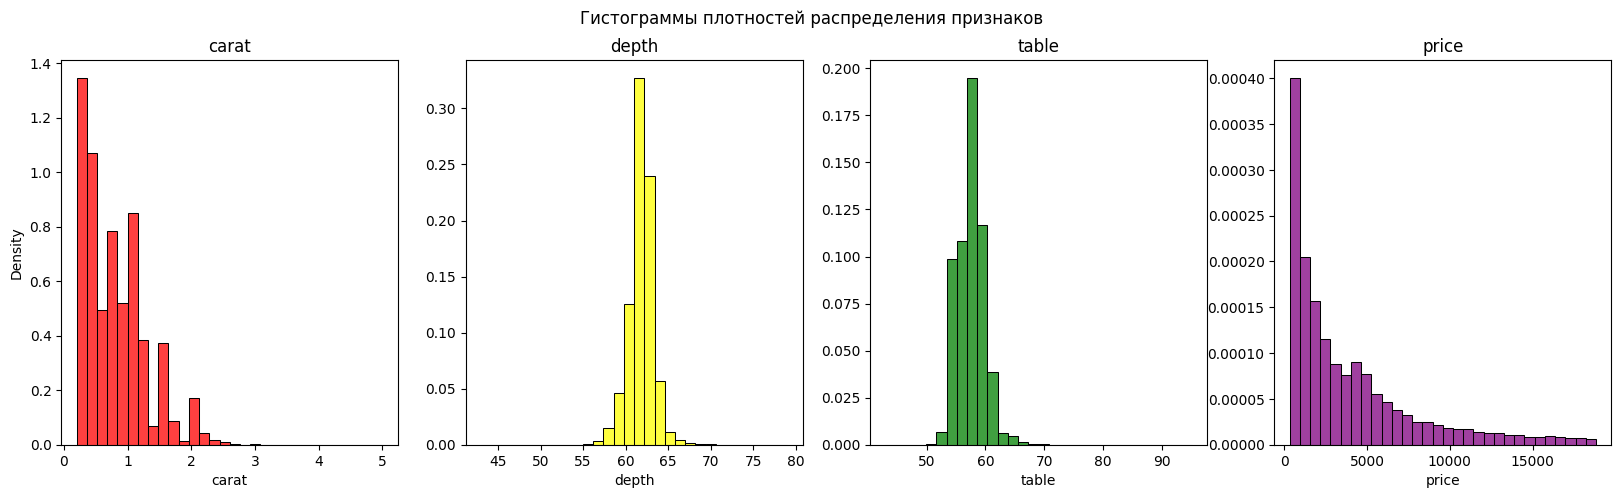

In [ ]:
# визуализация распределений выбранных переменных
fig, axes = plt.subplots(1, 4, figsize=(20,5))
fig.suptitle('Гистограммы плотностей распределения признаков')

sns.histplot(
    diamonds['carat'],
    bins=30,
    stat='density',
    color='red',
    ax=axes[0]
    )
axes[0].set_title('carat')
axes[0].set_ylabel('Density')

sns.histplot(
    diamonds['depth'],
    bins=30,
    stat='density',
    color='yellow',
    ax=axes[1]
    )
axes[1].set_title('depth')
axes[1].set_ylabel('')

sns.histplot(
    diamonds['table'],
    bins=30,
    stat='density',
    color='green',
    ax=axes[2]
    )
axes[2].set_title('table')
axes[2].set_ylabel('')

sns.histplot(
    diamonds['price'],
    bins=30,
    stat='density',
    color='purple',
    ax=axes[3]
    )
axes[3].set_title('price')
axes[3].set_ylabel('')

plt.show()

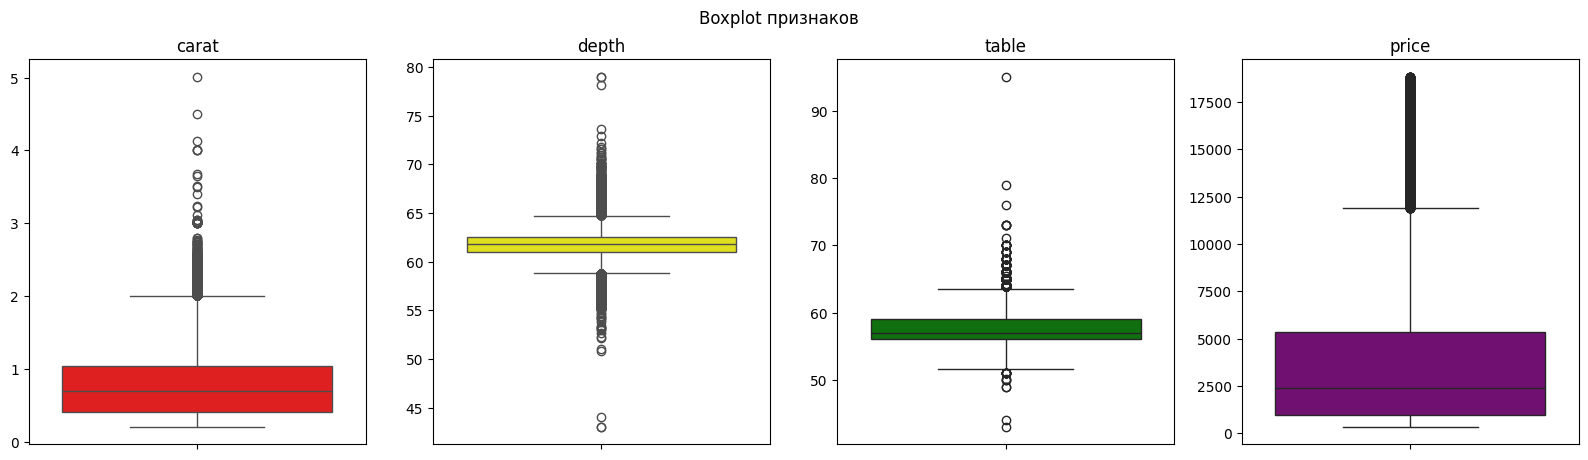

In [ ]:
# визуализация распределений выбранных переменных
fig, axes = plt.subplots(1, 4, figsize=(20,5))
fig.suptitle('Boxplot признаков')

sns.boxplot(y=diamonds['carat'], color='red', ax=axes[0])
axes[0].set_title('carat')
axes[0].set_ylabel('')

sns.boxplot(y=diamonds['depth'], color='yellow', ax=axes[1])
axes[1].set_title('depth')
axes[1].set_ylabel('')

sns.boxplot(y=diamonds['table'], color='green', ax=axes[2])
axes[2].set_title('table')
axes[2].set_ylabel('')

sns.boxplot(y=diamonds['price'], color='purple', ax=axes[3])
axes[3].set_title('price')
axes[3].set_ylabel('')

plt.show()

Выводы по предварительному анализу:

1.   Пропусков нет ни в одном столбце
2.   В столбцах `carat`, `depth`, `table` и `price` явных некорректных значений не обнаружено.
3.   `depth` и `table` имеют распределения плотностей, близкие к нормальному.
4.   `carat` и `price` имеют логнормальные распределения плотностей
5.   У всех четырех признаков имеется существенное количество значений за пределами межквартильного интервала. Особенно выделяются экстремальные значения для признаков `carat` и `price`, которые являются, вероятнее всего, *естественными выбросами*, так как существует слишком крупные и, соответственно, очень дорогие бриллианты. Экстремальные значения размерных характеристик также могут быть *естественными выбросами* в случае реальных крупных бриллиантов, при этом часть экстремальных значений в этих размерных характеристиках (x, y, z, depth, table) может быть связана и с ошибками измерения или ввода данных, т.е быть *синтетическими выбросами*.

1.2. Обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины.

In [ ]:
diamonds_clean = diamonds.copy()

In [ ]:
# целевая переменная
y = diamonds['price']

# признаки
X = diamonds[['carat', 'table', 'depth']]

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# коэффициенты модели
print(f'Свободный член: {model.intercept_}')

coef_df = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : model.coef_
})
coef_df

Свободный член: 13056.321710255175


,Feature,Coefficient
0,carat,7873.053292
1,table,-106.418133
2,depth,-150.407643


### Шаг 2. Обработка признаков

2.1. Реализуйте модельный метод для анализа выбросов.
- Постройте линейную модель для описания данных
- Визуализируйте предсказания

*Определите выбросы по графику предсказаний. Где модель ошибается сильнее всего?*

In [ ]:
# получение предсказаний
y_pred = model.predict(X_test)

# получение остатков
residuals = y_test - y_pred

# Установите пороговое значение
# Общепринятое пороговое значение - три стандартных отклонения
threshold = 3 * residuals.std()

# Определите выбросы
# (воспользуйтесь методом np.abs для получения значения по модулю)
outliers = residuals[np.abs(residuals) > threshold]

Визуализируйте предсказанную линию на графике и определите выбросы.

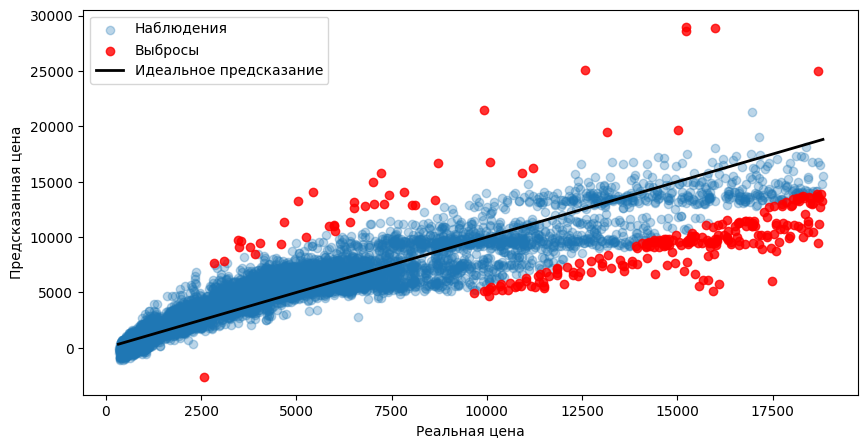

In [ ]:
# индексы выбросов
outliers_idx = np.abs(residuals) > threshold

plt.figure(figsize=(10,5))

# Обычные точки
plt.scatter(
    y_test[~outliers_idx],
    y_pred[~outliers_idx],
    alpha=0.3,
    label='Наблюдения'
)

# Выбросы
plt.scatter(
    y_test[outliers_idx],
    y_pred[outliers_idx],
    color='red',
    alpha=0.8,
    label='Выбросы'
)

# Линия регрессии
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linewidth=2,
    color='black',
    label='Идеальное предсказание'
)

plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.legend()
plt.show()

*Построение предсказанной линии регрессии не выполнялось, так как модель одновременно использует несколько признаков `(carat, table, depth)` и описывает данные гиперплоскостью в многомерном пространстве. Выбросы были определены и визуализированы как данные, выходящие за пороговое значение - три стандартных отклонения остатков. По графику (по отклонению от линии идеального предсказания) видно, что наибольшие ошибки модель допускает для бриллиантов с высокими значениями цены, то есть линейная модель хуже всего описывает экстремальные значения целевой переменной.*

2.2. Реализуйте метод опорных векторов (SVM) для поиска выбросов.

In [ ]:
# масштабирование признаков перед SVM из-за его чувствительности к масштабу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.19816781, -1.09967199, -0.17409151],
       [-1.24036129,  1.58552871, -1.36073849],
       [-1.19816781,  3.37566251, -3.38501862],
       ...,
       [-0.20662095,  1.13799526,  0.73334442],
       [ 0.13092691,  0.24292836, -0.52310533],
       [-0.10113725, -1.09967199,  0.31452784]])

In [ ]:
svm = OneClassSVM(nu=0.03, kernel='rbf')
svm.fit(X_scaled)
svm_pred = svm.predict(X_scaled)

svm_outliers = X_scaled[svm_pred == -1]

print(f'Количество выбросов, найденных с помощью SVM: {len(svm_outliers)}')

Количество выбросов, найденных с помощью SVM: 1620


In [ ]:
# корреляционная матрица числовых признаков
corr_matrix = diamonds[['carat', 'depth', 'table', 'price']].corr()

corr_matrix['price'].sort_values(ascending=False)

,price
price,1.000000
carat,0.921591
table,0.127134
depth,-0.010647


*Согласно корреляционной матрице признаком, наиболее влияющим на цену, вполне логично является `carat`. Его определение было необходимо для последующей визуализации работы `SVM` и `Isolation Forest`.*

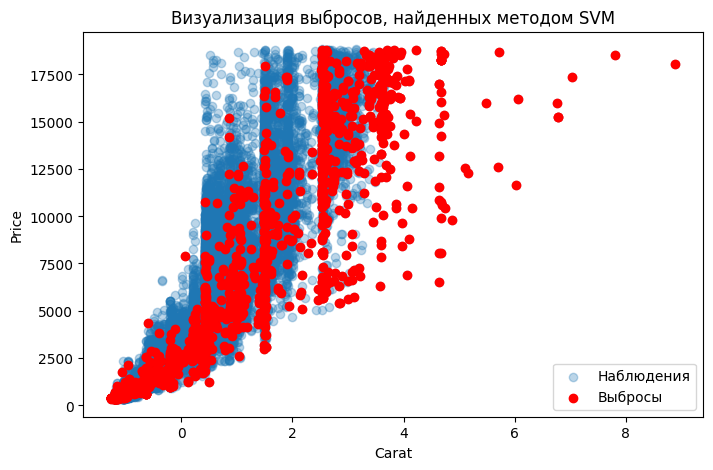

In [ ]:
# визуализация svm
plt.figure(figsize=(8,5))

plt.scatter(
    # все строки и первый столбец, в котором был признак carat
    X_scaled[:, 0],
    y,
    alpha=0.3,
    label='Наблюдения'
)

plt.scatter(
    X_scaled[svm_pred == -1, 0],
    y.loc[svm_pred == -1],
    color='red',
    label='Выбросы'
)

plt.xlabel('Carat')
plt.ylabel('Price')
plt.title('Визуализация выбросов, найденных методом SVM')

plt.legend()
plt.show()

2.3. Реализуйте алгоритм Isolation Forest

In [ ]:
isol = IsolationForest(contamination=0.03, random_state=42)
isol.fit(X)
isol_pred = isol.predict(X)

isol_outliers = X[isol_pred == -1]

print(f'Количество выбросов, найденных с помощью Isolation Forest: {len(isol_outliers)}')

Количество выбросов, найденных с помощью Isolation Forest: 1619


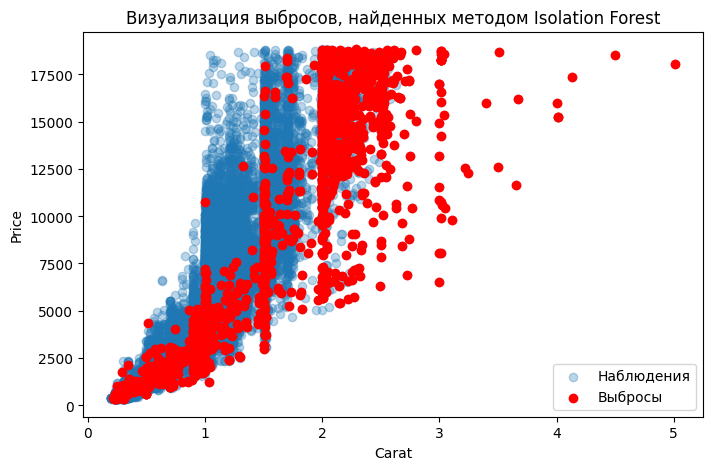

In [ ]:
# визуализация isolation forest
plt.figure(figsize=(8,5))

plt.scatter(
    X['carat'],
    y,
    alpha=0.3,
    label='Наблюдения'
)

plt.scatter(
    X.loc[isol_pred == -1, 'carat'],
    y.loc[isol_pred == -1],
    color='red',
    label='Выбросы'
)

plt.xlabel('Carat')
plt.ylabel('Price')
plt.title('Визуализация выбросов, найденных методом Isolation Forest')

plt.legend()
plt.show()

In [ ]:
svm_idx = set(X.index[svm_pred == -1])
isol_idx = set(X.index[isol_pred == -1])

common = svm_idx & isol_idx

print(f'Совпадающих выбросов: {len(common)}')

Совпадающих выбросов: 1051


2.4. Сравните работу методов: какой из них предпочтительнее для вашей задачи?

2.5. Удалите выбросы выбранным методом

*Несмотря на практически равное количество найденных выбросов, для данной задачи более предпочтительным является `Isolation Forest`, так как он лучше подходит для поиска выбросов в многомерных данных большого объема, к которым относится анализируемый датасет `diamonds`. Также этот метод не требует предположений о структуре распределения признаков.*

In [ ]:
# удаление выбросов, найденных Isolation Forest
diamonds_clean = diamonds_clean[isol_pred == 1]

print(f'Размерность датасета до удаления выбросов: {diamonds.shape}')
print(f'Размерность датасета после удаления выбросов: {diamonds_clean.shape}')
print(f'Удалено выбросов: {(isol_pred == -1).sum()}')

Размерность датасета до удаления выбросов: (53940, 10)
Размерность датасета после удаления выбросов: (52321, 10)
Удалено выбросов: 1619


### Часть 3. Обучение

Снова обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины - после улучшения признаков. Как поменялось качество предсказания после удаления выбросов?

In [ ]:
# целевая переменная
y_clean = diamonds_clean['price']

# признаки
X_clean = diamonds_clean[['carat', 'table', 'depth']]

# разделение на обучающую и тестовую выборки
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

# обучение модели
model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train_clean)

# предсказания
y_pred_clean = model_clean.predict(X_test_clean)

# коэффициенты модели
print(f'Свободный член: {model_clean.intercept_}')

coef_df_clean = pd.DataFrame({
    'Feature' : X_clean.columns,
    'Coefficient' : model_clean.coef_
})
coef_df_clean

Свободный член: 11123.806363314934


,Feature,Coefficient
0,carat,8032.966767
1,table,-104.474072
2,depth,-122.605505


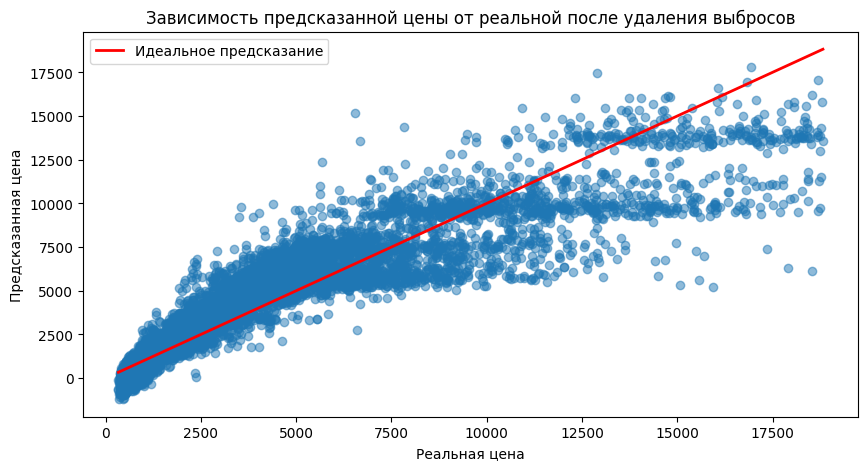

In [ ]:
# визуализация результата обучения на очищенных данных
plt.figure(figsize=(10,5))

plt.scatter(
    y_test_clean,
    y_pred_clean,
    alpha=0.5
)

plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    color='red',
    linewidth=2,
    label='Идеальное предсказание'
)

plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Зависимость предсказанной цены от реальной после удаления выбросов')
plt.legend()

plt.show()

In [ ]:
print('Значения метрик до удаления выбросов:')
print(f'R²: {r2_score(y_test, y_pred):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print('\nЗначения метрик после удаления выбросов:')
print(f'R²: {r2_score(y_test_clean, y_pred_clean):.4f}')
print(f'MAE: {mean_absolute_error(y_test_clean, y_pred_clean):.2f}')

Значения метрик до удаления выбросов:
R²: 0.8532
MAE: 994.74

Значения метрик после удаления выбросов:
R²: 0.8486
MAE: 978.66


### Итоги (рефлексия)

Напишите выводы (5–7 предложений):

1. Какой метод поиска выбросов вы сочли наиболее предпочтительным?
2. Как сильно выросла точность модели после очистки?

**Выводы:**

1.   Несмотря на практически равный показатель с методом One-Class SVM, наиболее предпочтительным был выбран метод Isolation Forest. Этот метод лучше подходит для многомерных данных большого объема и не требует предположений о распределении признаков. В целом, он является одним из наиболее универсальных методов для поиска аномалий.
2.   После очистки (удаления выбросов) точность модели выросло незначительно. Коэффициент детерминации R² практически не изменился (0.8532 -> 0.8486), а средняя абсолютная ошибка МАЕ (для цены) уменьшилась с 994 до 978 долларов. Это означает, что модель стала немного точнее предсказывать цены бриллиантов. Но эффект небольшой, и его вероятнее всего можно объяснить тем многие обнаруженные и удаленные выбросы не являются ошибками измерений или ввода, они - естественная особенность данных.

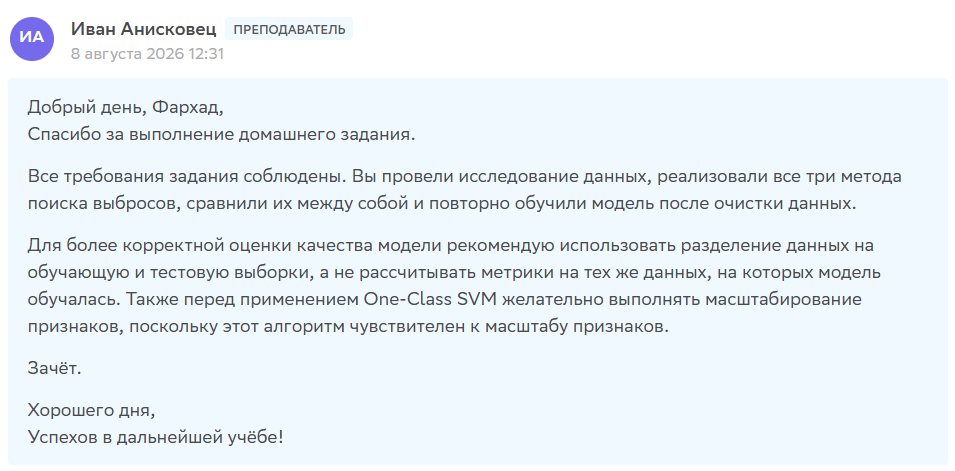

**Корректировки согласно замечаниям внесены**